# Librerias
---

## Instalación

In [2]:
!pip install opendatasets
!pip install sounddevice
!pip install librosa
!pip install opendatasets
!pip install torchaudio
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because norma

## Importación

In [3]:
#Importacion de Librerias
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Audio
import soundfile as sf
from numpy import pi
import os
import pandas as pd
from itertools import product
import uuid
from tqdm import tqdm
from collections import defaultdict
import torchaudio
import torchaudio.transforms as T
import torch
import gc
import os
from sklearn.preprocessing import MultiLabelBinarizer

In [4]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3060 Ti'

# Carga de datos
---

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")

print("Path to dataset files:", path)
#!sudo mv /home/camsp/.cache/kagglehub/datasets/vbookshelf/respiratory-sound-database/versions/2 /home/camsp/Desktop/stetho/Breath_IAv3.ipynb

  3%|▎         | 101M/3.69G [00:03<01:49, 35.3MB/s] 


KeyboardInterrupt: 

In [5]:
path = "./2"

In [6]:
path_sounds = path + "/Respiratory_Sound_Database/Respiratory_Sound_Database"
demo_data = pd.read_csv(path+"/demographic_info.txt", delim_whitespace=True, header=None)
demo_data.columns = [
    'Patient_number',
   'Age',
   'Sex',
   'Adult_BMI_kg_m2',
  'Child_Weight_kg',
   "Child_Height_cm"
]

demo_data

/tmp/ipykernel_319000/1257289098.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  demo_data = pd.read_csv(path+"/demographic_info.txt", delim_whitespace=True, header=None)


,Patient_number,Age,Sex,Adult_BMI_kg_m2,Child_Weight_kg,Child_Height_cm
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0
...,...,...,...,...,...,...
121,222,60.00,M,NaN,NaN,NaN
122,223,NaN,NaN,NaN,NaN,NaN
123,224,10.00,F,NaN,32.3,143.0
124,225,0.83,M,NaN,7.8,74.0


# Análisis exploratorio
---

## Información demografica

Número de pacientes

In [7]:
demo_data.shape[0]

126

Pacientes por sexo

In [8]:
demo_data["Sex"].value_counts()

Sex
M    79
F    46
Name: count, dtype: int64

Edades de los pacientes

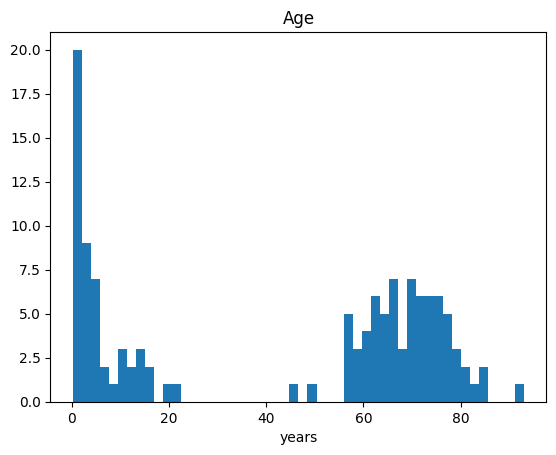

In [9]:
demo_data.hist("Age", bins=50)
plt.xlabel("years")
plt.grid()

### Niños

Los pacientes estan separados en niños y adultos, a continuación se realiza el análisis para los niños:

In [10]:
demo_childs = demo_data.dropna(subset=["Child_Weight_kg"])
print("Número de pacientes: " + str(demo_childs.shape[0]))

Número de pacientes: 44


Desviación estandar: 4.145251540085175
Promedio: 4.251818181818182


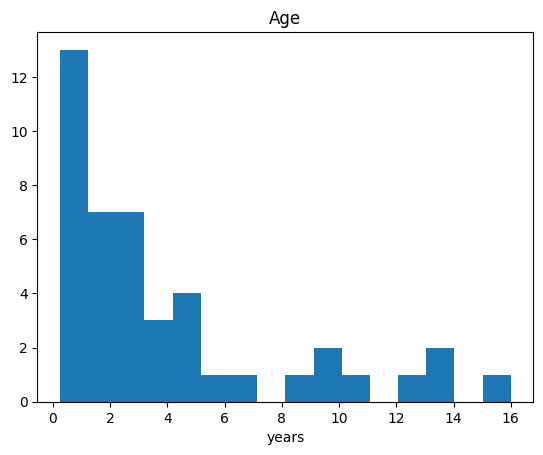

In [11]:
# Distribución de las edades
demo_childs.hist("Age", bins=16)
plt.xlabel("years")
plt.title("Age")
plt.grid()
print("Desviación estandar: " + str(np.std(demo_childs['Age'])))
print("Promedio: " + str(np.mean(demo_childs['Age'])))

Desviación estandar: 16.95486846359383
Promedio: 21.361136363636362


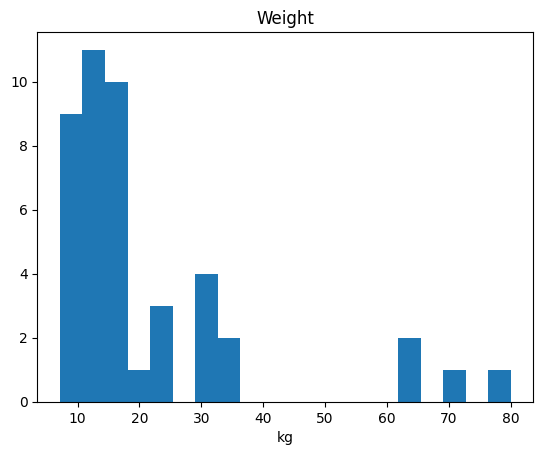

In [12]:
demo_childs.hist("Child_Weight_kg", bins=20)
plt.title("Weight")
plt.xlabel("kg")
plt.grid()
print("Desviación estandar: " + str(np.std(demo_childs['Child_Weight_kg'])))
print("Promedio: " + str(np.mean(demo_childs['Child_Weight_kg'])))

Desviación estandar: 30.424334230656303
Promedio: 104.65238095238094


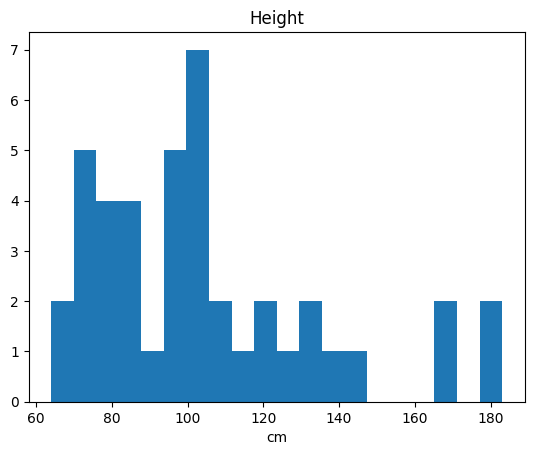

In [13]:
demo_childs.hist("Child_Height_cm", bins=20)
plt.title("Height")
plt.xlabel("cm")
plt.grid()
print("Desviación estandar: " + str(np.std(demo_childs['Child_Height_cm'])))
print("Promedio: " + str(np.mean(demo_childs['Child_Height_cm'])))

### Adultos

In [14]:
demo_adults = demo_data.dropna(subset=["Adult_BMI_kg_m2"])
print("Número de pacientes: " + str(demo_adults.shape[0]))

Número de pacientes: 75


Desviación estandar: 11.53031945206492
Promedio: 67.72


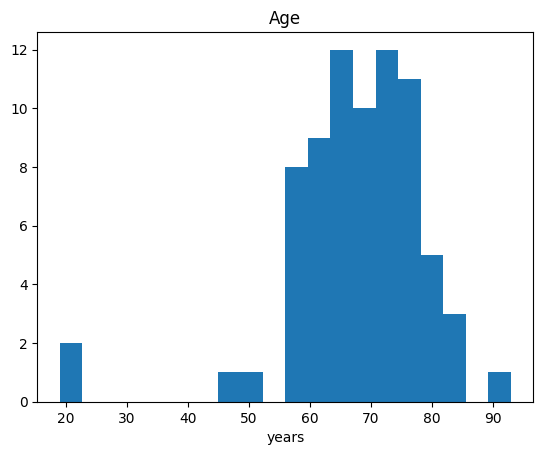

In [15]:
# Distribución de las edades
demo_adults.hist("Age", bins=20)
plt.xlabel("years")
plt.title("Age")
plt.grid()
print("Desviación estandar: " + str(np.std(demo_adults['Age'])))
print("Promedio: " + str(np.mean(demo_adults['Age'])))

Desviación estandar: 5.336581677441094
Promedio: 27.19


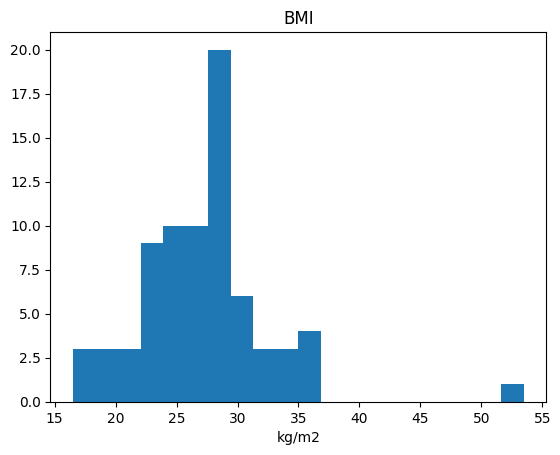

In [16]:
demo_adults.hist("Adult_BMI_kg_m2", bins=20)
plt.xlabel("kg/m2")
plt.title("BMI")
plt.grid()
print("Desviación estandar: " + str(np.std(demo_adults['Adult_BMI_kg_m2'])))
print("Promedio: " + str(np.mean(demo_adults['Adult_BMI_kg_m2'])))

### Pacientes con datos desconocidos

Algunos de los pacientes no cuentan con datos de altura, BMI, o peso

In [17]:
demo_unknown = demo_data[demo_data["Adult_BMI_kg_m2"].isna() & demo_data["Child_Weight_kg"].isna()]
print("Número de pacientes: " + str(demo_unknown.shape[0]))

Número de pacientes: 7


Se observa que la mayoria de los pacientes con datos desconocidos pertenecen al grupo de los niños, a excepción de dos pacientes, uno de 60 años, y otro del que desconoce la edad

In [18]:
demo_unknown

,Patient_number,Age,Sex,Adult_BMI_kg_m2,Child_Weight_kg,Child_Height_cm
7,108,3.0,M,NaN,NaN,NaN
82,183,14.0,F,NaN,NaN,NaN
89,190,3.0,F,NaN,NaN,NaN
96,197,16.0,F,NaN,NaN,NaN
116,217,12.0,F,NaN,NaN,NaN
121,222,60.0,M,NaN,NaN,NaN
122,223,NaN,NaN,NaN,NaN,NaN


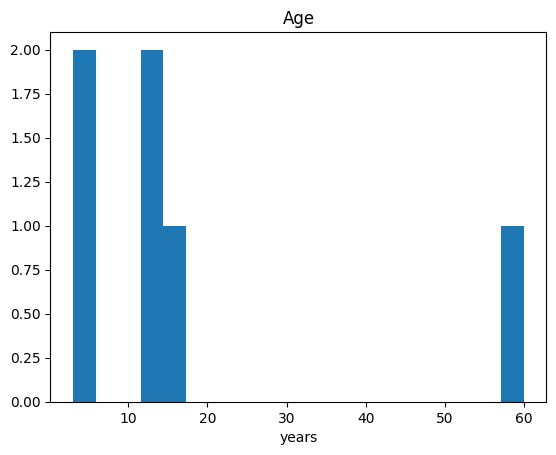

In [19]:
# Distribución de las edades
demo_unknown.hist("Age", bins=20)
plt.xlabel("years")
plt.title("Age")
plt.grid()

## Análisis de los diagnosticos


In [20]:
diag_data = pd.read_csv(path_sounds+"/patient_diagnosis.csv", header=None)
diag_data.columns = ["Patient", "Diagnosis"]
diag_data

,Patient,Diagnosis
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI
...,...,...
121,222,COPD
122,223,COPD
123,224,Healthy
124,225,Healthy


In [21]:
diag_data['Diagnosis'].value_counts()

Diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Pneumonia          6
Bronchiolitis      6
LRTI               2
Asthma             1
Name: count, dtype: int64

# Sibilancias y crepitantes

Cada uno de los archivos contiene metadata que proporciona información sobre la presencia de sibilancias y crepitantes en un determinado periodo de tiempo. A continuación se busca extraer dicha información:

In [22]:
def Extract_Annotation_Data(file_name, root):
    tokens = file_name.split('_')
    recording_info = pd.DataFrame(data = [tokens], columns = ['Patient number', 'Recording index', 'Chest location','Acquisition mode','Recording equipment'])
    recording_annotations = pd.read_csv(os.path.join(root, file_name + '.txt'), names = ['Start', 'End', 'Crackles', 'Wheezes'], delimiter= '\t')
    return (recording_info, recording_annotations)

In [23]:
filenames = [s.split('.')[0] for s in os.listdir(path = path_sounds+"/audio_and_txt_files") if '.txt' in s]

In [24]:
i_list = []
rec_annotations = []
rec_annotations_dict = {}
for s in filenames:
    (i,a) = Extract_Annotation_Data(s, path_sounds+"/audio_and_txt_files")
    i_list.append(i)
    rec_annotations.append(a)
    rec_annotations_dict[s] = a
recording_info = pd.concat(i_list, axis = 0)
recording_info.head()

,Patient number,Recording index,Chest location,Acquisition mode,Recording equipment
0,172,1b5,Al,mc,AKGC417L
0,117,1b2,Tc,mc,LittC2SE
0,207,3b2,Ar,mc,AKGC417L
0,174,1p4,Ll,mc,AKGC417L
0,135,2b1,Pl,mc,LittC2SE


In [25]:
no_label_list = []
crack_list = []
wheeze_list = []
both_sym_list = []
filename_list = []
for f in filenames:
    d = rec_annotations_dict[f]
    no_labels = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 0)].index)
    n_crackles = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 0)].index)
    n_wheezes = len(d[(d['Crackles'] == 0) & (d['Wheezes'] == 1)].index)
    both_sym = len(d[(d['Crackles'] == 1) & (d['Wheezes'] == 1)].index)
    no_label_list.append(no_labels)
    crack_list.append(n_crackles)
    wheeze_list.append(n_wheezes)
    both_sym_list.append(both_sym)
    filename_list.append(f)


Los audios pueden presentar sibilancias, crepitantes, ambos sintomas o ninguno. A continuación se lista la cantidad de ocurrencias de cada sintoma por audio

In [26]:
file_label_df = pd.DataFrame(data = {'filename':filename_list, 'no label':no_label_list, 'crackles only':crack_list, 'wheezes only':wheeze_list, 'crackles and wheezees':both_sym_list})
file_label_df.head()

,filename,no label,crackles only,wheezes only,crackles and wheezees
0,172_1b5_Al_mc_AKGC417L,5,1,1,0
1,117_1b2_Tc_mc_LittC2SE,7,0,0,0
2,207_3b2_Ar_mc_AKGC417L,9,0,0,0
3,174_1p4_Ll_mc_AKGC417L,1,4,0,0
4,135_2b1_Pl_mc_LittC2SE,4,5,0,0


Se puede observar que el conjunto de datos esta desbalanceado, pues la mayoria de los fragmentos de audio no presentan sintomas.
Tambien se observa que hay un sesgo en los sintomas, pues hay mayor presencia de crepitancias que de sibilancias

In [27]:
file_label_df[["no label","crackles only","wheezes only","crackles and wheezees"]].sum()

no label                 3642
crackles only            1864
wheezes only              886
crackles and wheezees     506
dtype: int64

Por otro lado, los audios estan segmentados por los momentos en los que hay presencia en los sintomas

In [28]:
sympt = pd.concat([
    df.assign(filename=filename)
    for filename, df in rec_annotations_dict.items()
], ignore_index=True)

sympt["Length"] = sympt["End"] - sympt["Start"]

sympt.head()

,Start,End,Crackles,Wheezes,filename,Length
0,1.010,3.581,0,0,172_1b5_Al_mc_AKGC417L,2.571
1,3.581,6.836,0,1,172_1b5_Al_mc_AKGC417L,3.255
2,6.836,9.624,1,0,172_1b5_Al_mc_AKGC417L,2.788
3,9.624,12.262,0,0,172_1b5_Al_mc_AKGC417L,2.638
4,12.262,15.801,0,0,172_1b5_Al_mc_AKGC417L,3.539


In [29]:
file_length = sympt[["filename","Length"]].groupby("filename").sum()
file_length.head()

,Length
filename,
101_1b1_Al_sc_Meditron,19.928
101_1b1_Pr_sc_Meditron,19.900
102_1b1_Ar_sc_Meditron,19.700
103_2b2_Ar_mc_LittC2SE,19.615
104_1b1_Al_sc_Litt3200,15.856


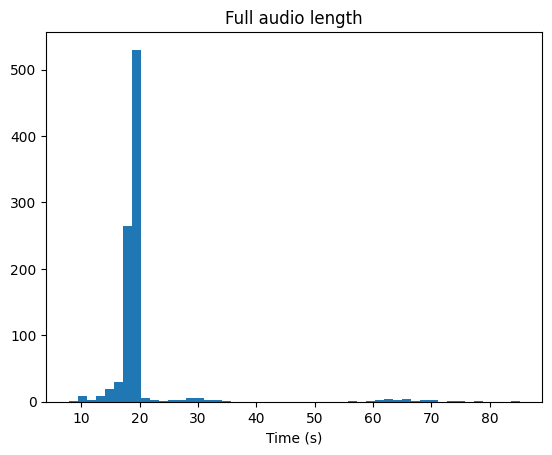

In [30]:
file_length.hist("Length", bins=50)
plt.title("Full audio length")
plt.xlabel("Time (s)")
plt.grid()

Desviación estandar: 1.1724491403827362
Promedio: 2.700509085242099


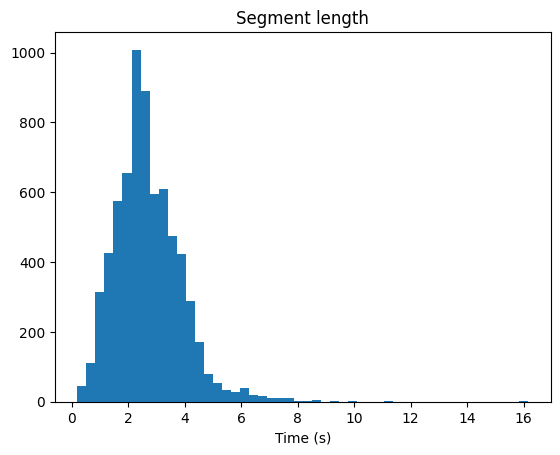

In [31]:
sympt.hist("Length", bins=50)
plt.grid()
plt.title("Segment length")
plt.xlabel("Time (s)")
print("Desviación estandar: " + str(np.std(sympt['Length'])))
print("Promedio: " + str(np.mean(sympt['Length'])))

# Preprocesamiento de los datos
---
Como cada uno de los microfonos utilizados tiene diferentes tiempos de muestreo, se utilizara un valor apropiado para las frecuencias de las sibilancias y las crepitancias, y que no sea exageradamente alto para las frecuencias tipicas de la campana y diafragma. El tiempo de muestreo elegido es de 4000 Hz.

Por otro lado, dado que se presenta un desbalance en los datos, se propone los siguientes metodos de data augmentation:

1. Compresión de tiempo manteniendo el pitch, factor de compresión (0.7, 0.9)
2. Corrimiento del pitch, factores (-2, 1)
3. Ruido blanco, SNR 10dB

Para el procesamiento de los datos se busca la siguiente linea de ejecución:

1. Re muestreo a 4000 Hz
2. Eliminación de nivel DC
3. Normalización
4. Espectrograma de mel

## Funciones utiles

In [32]:
# Preprocessing
def load_audio(filename, base_path):
  audio = librosa.load(base_path+"/"+filename, mono=True)
  return audio

def resamp_audio(audio, orig_sr):
  resamp_audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=4000, res_type="fft", fix=True, scale=True)
  return resamp_audio

def trim_audio(audio, start_time, end_time):
  trimed_audio = audio[int(start_time*4000):int(end_time*4000)]
  return trimed_audio

def stft_audio(audio):
  # Calcular STFT
  n_fft = 256
  hop_length = 64
  sr = 4000
  stride = int(n_fft/4)
  stft_values = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=stride))[:,:int(2*sr/(stride))]
  return stft_values

def lin2db(stft):
  # Convertir potencia a decibelios
  S_db = librosa.power_to_db(np.abs(S), ref=np.max)
  return S_db

def low_filter(stft):
  frequencies = librosa.fft_frequencies(sr=4000, n_fft=256)
  S_filtered = stft.copy()
  # Clear base signals (<1Hz)
  S_filtered[(frequencies >= 0) & (frequencies <= 1), :] = 0
  return S_filtered

def istft_audio(stft):
  audio = librosa.istft(stft, hop_length=64)
  return audio

def normalize_audio(audio):
  audio_norm = librosa.util.normalize(audio)
  return audio_norm

def mel_spectrogram(audio):
  # Calcular espectrograma de Mel
  S = librosa.feature.melspectrogram(y=audio, sr=4000, n_fft=256, hop_length=128, n_mels=64)

  # Convertir a decibelios
  S_db = librosa.power_to_db(S, ref=np.max)

  return S_db

def plot_mel_spectrogram(spectrogram):
  plt.figure(figsize=(10, 4))
  librosa.display.specshow(spectrogram, sr=4000, hop_length=128, x_axis='time', y_axis='hz', cmap='magma')
  plt.colorbar(format='%+2.0f dB')
  plt.title('Mel Spectrogram (4 kHz)')
  plt.tight_layout()
  plt.show()

path_audio = path_sounds+"/audio_and_txt_files"

In [33]:
%%timeit
temp_audio = load_audio("101_1b1_Al_sc_Meditron.wav", path_audio)
audio_resamp = resamp_audio(temp_audio[0], temp_audio[1])
trimed = trim_audio(audio_resamp, 13.036, 14.721)
freq_values = stft_audio(trimed)
filtered = low_filter(freq_values)
new_audio = istft_audio(filtered)
norm_audio = normalize_audio(new_audio)
mel_spec = mel_spectrogram(norm_audio)

12.8 ms ± 1.39 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Data augmentation

In [34]:
import os
import gc
import uuid
import torch
import torchaudio
import numpy as np
import pandas as pd
from tqdm import tqdm
from itertools import product
from collections import defaultdict
from scipy.signal import butter, filtfilt
import torchaudio.transforms as T
from sklearn.model_selection import train_test_split

# Augmentation functions
def butter_highpass_filter(data, cutoff=1.0, fs=4000.0, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

def generate_padded_samples(source, output_length):
    copy = np.zeros(output_length, dtype=np.float32)
    src_length = len(source)
    if src_length == 0:
        return copy
    frac = src_length / output_length
    if frac < 0.5:
        cursor = 0
        while (cursor + src_length) < output_length:
            copy[cursor:(cursor + src_length)] = source[:]
            cursor += src_length
    else:
        copy[:src_length] = source[:]
    return copy

def split_and_pad(waveform, start, end, sr=4000, desired_duration=4.0):
    output_len = int(desired_duration * sr)
    start_sample = int(start * sr)
    end_sample = int(end * sr)
    data = waveform[:, start_sample:end_sample].squeeze().cpu().numpy()
    total_len = len(data)
    n_slices = int(np.ceil(total_len / output_len))
    samples_per_slice = total_len // n_slices
    segments = []
    cursor = 0
    for _ in range(n_slices):
        end_idx = min(cursor + samples_per_slice, total_len)
        chunk = data[cursor:end_idx]
        padded = generate_padded_samples(chunk, output_len)
        segments.append(padded)
        cursor += samples_per_slice
    return segments

def normalize_waveform(waveform):
    max_val = waveform.abs().max()
    return waveform / (max_val + 1e-6)

def augment_add_noise(waveform, snr_db=10):
    noise = torch.randn_like(waveform)
    signal_power = waveform.norm(p=2)
    noise_power = noise.norm(p=2)
    factor = (signal_power / noise_power) / (10**(snr_db / 20))
    return waveform + factor * noise

def apply_specaugment(mel_tensor, time_mask_param=20, freq_mask_param=8):
    time_mask = T.TimeMasking(time_mask_param=time_mask_param)
    freq_mask = T.FrequencyMasking(freq_mask_param=freq_mask_param)
    augmented = freq_mask(time_mask(mel_tensor))
    return augmented

def split_train_val_by_filename(df, test_size=0.2, random_state=42):
    filenames = df[['filename', 'Crackles', 'Wheezes']].drop_duplicates()

    # Crear etiqueta combinada para estratificación
    filenames['label_combo'] = filenames['Crackles'].astype(str) + "_" + filenames['Wheezes'].astype(str)

    train_fnames, val_fnames = train_test_split(
        filenames, test_size=test_size, stratify=filenames['label_combo'], random_state=random_state
    )

    df_train = df[df['filename'].isin(train_fnames['filename'])]
    df_val = df[df['filename'].isin(val_fnames['filename'])]

    print("🔍 Archivos únicos en train:", df_train['filename'].nunique())
    print("🔍 Archivos únicos en val:", df_val['filename'].nunique())
    print("🚫 Archivos duplicados entre ambos:", len(set(df_train['filename']) & set(df_val['filename'])))
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True)


In [43]:
def generate_balanced_augmented_dataset(
    df_segments, base_path, output_dir, augment_config, max_per_class=None, desired_duration=4.0
):
    os.makedirs(output_dir, exist_ok=True)
    records = []
    label_counts = defaultdict(int)

    ts = 4000
    n_fft = 512
    hop_length = 128
    n_mels = 64
    mfcc_n = 64
    spect_size = int((desired_duration * ts - n_fft) / hop_length + 1)

    mel_transform = T.MelSpectrogram(sample_rate=ts, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels).to("cuda")
    db_transform = T.AmplitudeToDB(top_db=80).to("cuda")
    mfcc_transform = T.MFCC(
        sample_rate=ts,
        n_mfcc=mfcc_n,
        melkwargs={'n_fft': n_fft, 'hop_length': hop_length, 'n_mels': n_mels}
    ).to("cuda")

    df_segments['combo'] = df_segments['Crackles'].astype(str) + "_" + df_segments['Wheezes'].astype(str)
    label_distribution = df_segments['combo'].value_counts().to_dict()
    max_per_class = max_per_class or max(label_distribution.values())

    print("Distribución original:", label_distribution)
    print("Objetivo por clase:", max_per_class)

    def fix_size(mat, target_size):
        if mat.shape[-1] < target_size:
            pad = target_size - mat.shape[-1]
            mat = torch.nn.functional.pad(mat, (0, pad), value=mat.min() - 5)
        return mat[..., :target_size]

    for filename, group in tqdm(df_segments.groupby('filename')):
        full_path = os.path.join(base_path, filename + ".wav")
        waveform, sr = torchaudio.load(full_path)
        waveform = torchaudio.functional.resample(waveform, orig_freq=sr, new_freq=ts).to("cuda")

        waveform_np = waveform.squeeze().cpu().numpy()
        waveform_np_filtered = butter_highpass_filter(waveform_np, cutoff=1.0, fs=ts, order=5).copy()
        waveform = torch.tensor(waveform_np_filtered, dtype=torch.float32).unsqueeze(0).to("cuda")
        waveform = normalize_waveform(waveform)

        for _, row in group.iterrows():
            crackles = int(row["Crackles"])
            wheezes = int(row["Wheezes"])
            combo_key = f"{crackles}_{wheezes}"

            start, end = row['Start'], row['End']
            segments = split_and_pad(waveform, start, end, sr=ts, desired_duration=desired_duration)

            for padded_segment in segments:
                segment_tensor = torch.tensor(padded_segment, dtype=torch.float32).unsqueeze(0).to("cuda")

                mel = db_transform(mel_transform(segment_tensor))
                mfcc = mfcc_transform(segment_tensor)

                mel = fix_size(mel, spect_size)
                mfcc = fix_size(mfcc, spect_size)

                tensor2d = torch.stack([mel, mfcc], dim=0).cpu().numpy()
                npy_id = str(uuid.uuid4())
                npy_path = os.path.join(output_dir, f"{npy_id}.npy")
                np.save(npy_path, tensor2d)

                records.append({
                    'npy_path': npy_path,
                    'filename': filename,
                    'Crackles': crackles,
                    'Wheezes': wheezes,
                    'augmentations': 'none'
                })

                label_counts[combo_key] += 1
                if label_counts[combo_key] >= max_per_class:
                    break

                # AUGMENTACIÓN
                combos = list(product(augment_config['time_stretch'], augment_config['pitch_shift'], augment_config['snr']))
                np.random.shuffle(combos)

                for ts_rate, ps_shift, snr in combos:
                    augmented = segment_tensor.clone()
                    description = []

                    if snr is not None:
                        augmented = augment_add_noise(augmented, snr_db=snr)
                        description.append(f"SNR_{snr}dB")

                    if ps_shift != 0:
                        augmented = T.PitchShift(sample_rate=ts, n_steps=ps_shift).to("cuda")(augmented)
                        description.append(f"PS_{ps_shift}")

                    if ts_rate != 1.0 and augmented.shape[-1] >= 2048:
                        ts_np = librosa.effects.time_stretch(augmented.squeeze().cpu().detach().numpy(), rate=ts_rate)
                        augmented = torch.tensor(ts_np, dtype=torch.float32).unsqueeze(0).to("cuda")
                        description.append(f"TS_{ts_rate}")
                    else:
                        description.append(f"TS_{ts_rate}_skipped")

                    mel = db_transform(mel_transform(augmented))

                    if "specaugment" in augment_config.get("extra", []):
                        mel = apply_specaugment(mel)
                        description.append("SpecAug")

                    mfcc = mfcc_transform(augmented)

                    mel = fix_size(mel, spect_size)
                    mfcc = fix_size(mfcc, spect_size)

                    tensor2d = torch.stack([mel, mfcc], dim=0).cpu().detach().numpy()
                    npy_id = str(uuid.uuid4())
                    npy_path = os.path.join(output_dir, f"{npy_id}.npy")
                    np.save(npy_path, tensor2d)

                    records.append({
                        'npy_path': npy_path,
                        'filename': filename,
                        'Crackles': crackles,
                        'Wheezes': wheezes,
                        'augmentations': '+'.join(description)
                    })

                    label_counts[combo_key] += 1
                    if label_counts[combo_key] >= max_per_class:
                        break

        del waveform
        torch.cuda.empty_cache()
        gc.collect()

    return pd.DataFrame(records)


In [44]:
df_train, df_val = split_train_val_by_filename(sympt, test_size=0.2)


augment_config = {
    'time_stretch': [1.0, 0.9, 0.7, 1.1],
    'pitch_shift': [0, -2, 1],
    'snr': [None, 10],
    'extra': ['specaugment']
}

output_dir = "mel_balanced_dataset"

train_df = generate_balanced_augmented_dataset(
    df_train,
    base_path="./2/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files",  # sin .wav al final
    output_dir="mel_balanced_dataset/train",
    augment_config=augment_config,
    max_per_class=3000  # o el número que desees
)

val_df = generate_balanced_augmented_dataset(
    df_val,
    base_path="./2/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files",
    output_dir="mel_balanced_dataset/val",
    augment_config=augment_config,
    max_per_class=1000
)


🔍 Archivos únicos en train: 816
🔍 Archivos únicos en val: 280
🚫 Archivos duplicados entre ambos: 176
Distribución original: {'0_0': 3078, '1_0': 1696, '0_1': 851, '1_1': 491}
Objetivo por clase: 3000


100%|██████████| 816/816 [06:38<00:00,  2.05it/s]


Distribución original: {'0_0': 1063, '1_0': 588, '0_1': 340, '1_1': 193}
Objetivo por clase: 1000


100%|██████████| 280/280 [02:24<00:00,  1.93it/s]


In [45]:
train_df.to_csv("mel_balanced_dataset_train.csv", index=False)
val_df.to_csv("mel_balanced_dataset_val.csv", index=False)

In [46]:
train_df

,npy_path,filename,Crackles,Wheezes,augmentations
0,mel_balanced_dataset/train/f3df971b-4633-4ee6-...,101_1b1_Al_sc_Meditron,0,0,none
1,mel_balanced_dataset/train/87d64171-3d33-4d60-...,101_1b1_Al_sc_Meditron,0,0,PS_-2+TS_0.9+SpecAug
2,mel_balanced_dataset/train/a958d9cc-163b-40d2-...,101_1b1_Al_sc_Meditron,0,0,SNR_10dB+PS_1+TS_1.1+SpecAug
3,mel_balanced_dataset/train/0eb45770-43a9-47eb-...,101_1b1_Al_sc_Meditron,0,0,SNR_10dB+TS_1.0_skipped+SpecAug
4,mel_balanced_dataset/train/23206faf-64d9-4f82-...,101_1b1_Al_sc_Meditron,0,0,TS_0.9+SpecAug
...,...,...,...,...,...
17643,mel_balanced_dataset/train/ff19c0ab-2ea5-4f96-...,226_1b1_Pl_sc_LittC2SE,1,0,none
17644,mel_balanced_dataset/train/42b42c4c-24e1-48b1-...,226_1b1_Pl_sc_LittC2SE,0,0,none
17645,mel_balanced_dataset/train/3ffc7940-7d90-494f-...,226_1b1_Pl_sc_LittC2SE,0,0,none
17646,mel_balanced_dataset/train/00e2c869-9918-4eaf-...,226_1b1_Pl_sc_LittC2SE,1,0,none


In [47]:
train_df.shape

(17648, 5)

In [50]:
train_df["Wheezes"].value_counts()

Wheezes
0    10537
1     7111
Name: count, dtype: int64

In [49]:
train_df["Crackles"].value_counts()

Crackles
0    9700
1    7948
Name: count, dtype: int64

Cantidad total de datos: 20.698

Cantidad de datos por sintoma:
* Ninguno: 7092
* Crepitantes:	9270
* Sibilancias:	8292

Cantidad total por combinación:
* Ninguno: 7092
* Solo Sibilancias:	4336
* Solo Crepitantes:	5314
* Ambos: 3956

In [51]:
#!zip -r /content/dataset_augment.zip /mel_balanced_dataset/

In [52]:
#!rm -r /home/camsp/Desktop/stetho/mel_balanced_dataset
#!rm /dataset_augment.zip

## T-SNE

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

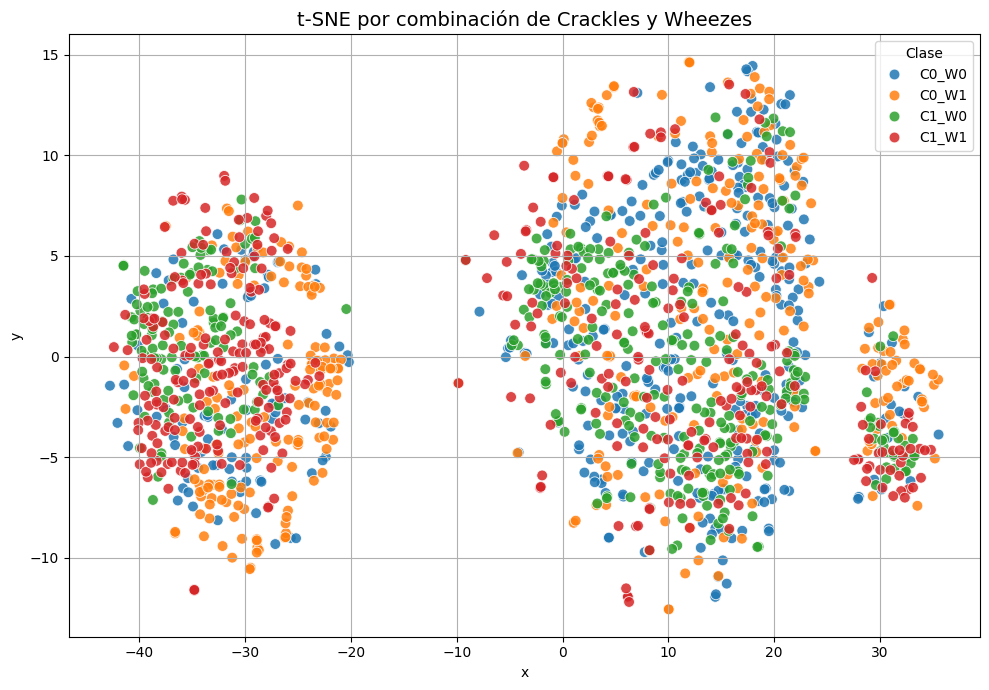

In [55]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Submuestreo balanceado por clase binaria combinada
train_df["label_bin"] = train_df["Crackles"].astype(str) + "_" + train_df["Wheezes"].astype(str)
df_sampled = train_df.groupby("label_bin").sample(n=400, random_state=42)

# 🔹 Extraer espectrogramas
features = []
labels = []

for _, row in df_sampled.iterrows():
    data = np.load(row["npy_path"])  # (2, 64, 122)
    features.append(data.flatten())
    labels.append(f"C{row['Crackles']}_W{row['Wheezes']}")  # para mejor visualización

X = np.array(features)
y = np.array(labels)

# 🔹 Normalización
X_scaled = StandardScaler().fit_transform(X)

# 🔹 t-SNE
tsne = TSNE(n_components=2, perplexity=60, random_state=42, init="pca", learning_rate="auto", n_iter=1000)
X_embedded = tsne.fit_transform(X_scaled)

# 🔹 Plotting
tsne_df = pd.DataFrame({
    "x": X_embedded[:, 0],
    "y": X_embedded[:, 1],
    "label": y
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="label", palette="tab10", s=60, alpha=0.85)
plt.title("t-SNE por combinación de Crackles y Wheezes", fontsize=14)
plt.legend(title="Clase", loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


# Modelo (Replica RDLINet)
---

In [1]:
import tensorflow as tf
#Importacion de Librerias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import sklearn as sk
from tensorflow.keras.utils import to_categorical

2025-07-16 14:42:33.283158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752694953.295399  337029 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752694953.299922  337029 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752694953.310227  337029 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752694953.310244  337029 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752694953.310245  337029 computation_placer.cc:177] computation placer alr

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs available:", gpus)
else:
    print("No GPUs found by TensorFlow.")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## RDLINet

In [3]:
class MFLI_bock(tf.keras.layers.Layer):
    def __init__(self, filters):
        super(MFLI_bock, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(filters, 1, padding='same')
        self.act1 = tf.keras.layers.LeakyReLU(0.3)

        self.dwconv2 = tf.keras.layers.DepthwiseConv2D(kernel_size = (3,3), strides = 1, padding = 'same')
        self.act2 = tf.keras.layers.LeakyReLU(0.3)
        self.conv2 = tf.keras.layers.Conv2D(filters, 1)
        self.act2b = tf.keras.layers.LeakyReLU(0.3)

        self.dwconv3 = tf.keras.layers.DepthwiseConv2D(kernel_size = (5,5), strides = 1, padding = 'same')
        self.act3 = tf.keras.layers.LeakyReLU(0.3)
        self.conv3 = tf.keras.layers.Conv2D(filters, 1)
        self.act3b = tf.keras.layers.LeakyReLU(0.3)

        self.pool4 = tf.keras.layers.MaxPool2D(pool_size = (3,3), strides = 1, padding = 'same')
        self.conv4 = tf.keras.layers.Conv2D(filters, 1)
        self.act4 = tf.keras.layers.LeakyReLU(0.3)

        self.concat = tf.keras.layers.Concatenate()

    def call(self, inputs):
        p1 = self.act1(self.conv1(inputs))
        p2 = self.act2b(self.conv2(self.act2(self.dwconv2(inputs))))
        p3 = self.act3b(self.conv3(self.act3(self.dwconv3(inputs))))
        p4 = self.act4(self.conv4(self.pool4(inputs)))
        return self.concat([p1, p2, p3, p4])


In [4]:
def RDLINet(input_size, output_size):
  input = tf.keras.layers.Input(shape=input_size)
  conv2d1 = tf.keras.layers.Conv2D(filters=16, kernel_size=3, strides=2, padding="same")(input)
  leakyR1 = tf.keras.layers.LeakyReLU(negative_slope=0.3)(conv2d1)
  maxPool1 = tf.keras.layers.MaxPool2D(pool_size=(3,3), strides=2, padding="same")(leakyR1)
  deepWise1 = tf.keras.layers.DepthwiseConv2D(kernel_size=3, strides = 1, padding="same")(maxPool1)
  leakyR2 = tf.keras.layers.LeakyReLU(negative_slope=0.3)(deepWise1)
  conv2d2 = tf.keras.layers.Conv2D(filters=32, kernel_size=1)(leakyR2)
  leakyR3 = tf.keras.layers.LeakyReLU(negative_slope=0.3)(conv2d2)
  maxPool2 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2, padding="same")(leakyR3)
  MFLI1 = MFLI_bock(24)(maxPool2)
  MFLI2 = MFLI_bock(24)(MFLI1)
  MFLI3 = MFLI_bock(24)(MFLI2)
  MFLI4 = MFLI_bock(24)(MFLI3)
  maxPool3 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2, padding="same")(MFLI4)
  dop = tf.keras.layers.Dropout(0.3)(maxPool3)
  GAP = tf.keras.layers.GlobalAveragePooling2D()(dop)
  #GLU
  dense1 = tf.keras.layers.Dense(32, activation="sigmoid", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(GAP)
  dense2 = tf.keras.layers.Dense(32, activation="linear", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(GAP)
  mult1 = tf.keras.layers.Multiply(name="glu_output")([dense1, dense2])
  output = tf.keras.layers.Dense(output_size, activation="sigmoid")(mult1)

  model = tf.keras.models.Model(inputs=input, outputs=output)
  return model


In [30]:
model = RDLINet((64, 122, 2), 2)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["binary_accuracy", tf.keras.metrics.AUC(name="AUC")]
)

In [31]:
model.summary()
#tf.keras.utils.plot_model(model,show_shapes=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 122,   │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 61,    │        304 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_27      │ (None, 32, 61,    │          0 │ conv2d_18[0][0]   │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 31,    │          0 │ leaky_re_lu_27[0… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_9  │ (None, 16, 31,    │        160 │ max_pooling2d_7[… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_28      │ (None, 16, 31,    │          0 │ depthwise_conv2d… │
│ (LeakyReLU)         │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 31,    │        544 │ leaky_re_lu_28[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_29      │ (None, 16, 31,    │          0 │ conv2d_19[0][0]   │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 8, 16, 32) │          0 │ leaky_re_lu_29[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_4         │ (None, 8, 16, 96) │      4,320 │ max_pooling2d_8[… │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_5         │ (None, 8, 16, 96) │     12,768 │ mfli_bock_4[0][0] │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_6         │ (None, 8, 16, 96) │     12,768 │ mfli_bock_5[0][0] │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfli_bock_7         │ (None, 8, 16, 96) │     12,768 │ mfli_bock_6[0][0] │
│ (MFLI_bock)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 4, 8, 96)  │          0 │ mfli_bock_7[0][0] │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 4, 8, 96)  │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 96)        │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      3,104 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 49,906 (194.95 KB)

 Trainable params: 49,906 (194.95 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_loss',       # Puedes cambiarlo a 'val_accuracy' si prefieres
        patience=50,              # Número de epochs sin mejora antes de detener
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath='best_model.keras', # Puedes usar .keras si usas formato nuevo
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,  # Cambia a True si quieres solo pesos
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,               # Reduce a la mitad
        patience=10,               # Epochs sin mejora antes de reducir LR
        min_lr=1e-6,              # No reducirá más allá de esto
        verbose=1
    )
]

## Load dataset
---

In [9]:
# Carga los CSV
train_df = pd.read_csv("mel_balanced_dataset_train.csv")
val_df = pd.read_csv("mel_balanced_dataset_val.csv")

# Asegura que sean enteros
train_df[["Crackles", "Wheezes"]] = train_df[["Crackles", "Wheezes"]].astype(int)
val_df[["Crackles", "Wheezes"]] = val_df[["Crackles", "Wheezes"]].astype(int)

# Genera la columna y con vectores binarios
train_df["y"] = train_df[["Crackles", "Wheezes"]].values.tolist()
val_df["y"] = val_df[["Crackles", "Wheezes"]].values.tolist()

In [10]:
train_df

,npy_path,filename,Crackles,Wheezes,augmentations,y
0,mel_balanced_dataset/train/f3df971b-4633-4ee6-...,101_1b1_Al_sc_Meditron,0,0,none,"[0, 0]"
1,mel_balanced_dataset/train/87d64171-3d33-4d60-...,101_1b1_Al_sc_Meditron,0,0,PS_-2+TS_0.9+SpecAug,"[0, 0]"
2,mel_balanced_dataset/train/a958d9cc-163b-40d2-...,101_1b1_Al_sc_Meditron,0,0,SNR_10dB+PS_1+TS_1.1+SpecAug,"[0, 0]"
3,mel_balanced_dataset/train/0eb45770-43a9-47eb-...,101_1b1_Al_sc_Meditron,0,0,SNR_10dB+TS_1.0_skipped+SpecAug,"[0, 0]"
4,mel_balanced_dataset/train/23206faf-64d9-4f82-...,101_1b1_Al_sc_Meditron,0,0,TS_0.9+SpecAug,"[0, 0]"
...,...,...,...,...,...,...
17643,mel_balanced_dataset/train/ff19c0ab-2ea5-4f96-...,226_1b1_Pl_sc_LittC2SE,1,0,none,"[1, 0]"
17644,mel_balanced_dataset/train/42b42c4c-24e1-48b1-...,226_1b1_Pl_sc_LittC2SE,0,0,none,"[0, 0]"
17645,mel_balanced_dataset/train/3ffc7940-7d90-494f-...,226_1b1_Pl_sc_LittC2SE,0,0,none,"[0, 0]"
17646,mel_balanced_dataset/train/00e2c869-9918-4eaf-...,226_1b1_Pl_sc_LittC2SE,1,0,none,"[1, 0]"


In [23]:
def load_npy_and_label(path, crackle, wheeze):
    def _load(path_):
        spec = np.load(path_.decode("utf-8"))  # ← shape: (2, 1, 64, 122)
        if spec.shape == (2, 1, 64, 122):
            spec = np.squeeze(spec, axis=1)  # → (2, 64, 122)
        elif spec.shape == (2, 64, 122):
            pass
        else:
            raise ValueError(f"Unexpected shape: {spec.shape}")
        return spec.astype(np.float32)
    spec = tf.numpy_function(_load, [path], tf.float32)
    spec.set_shape([2, 64, 122])  # ahora shape fija y correcta
    spec = tf.transpose(spec, perm=[1, 2, 0])  # → (64, 122, 2)

    label = tf.stack([crackle, wheeze])
    return spec, tf.cast(label, tf.float32)

def create_dataset(df, batch_size=32, shuffle=True):
    paths = df['npy_path'].values
    crackles = df['Crackles'].values.astype(np.float32)
    wheezes = df['Wheezes'].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, crackles, wheezes))
    ds = ds.map(load_npy_and_label, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [24]:
train_ds = create_dataset(train_df, batch_size=512, shuffle=True)
val_ds = create_dataset(val_df, batch_size=512, shuffle=False)

In [21]:
np_espec = np.load("./mel_balanced_dataset/train/0001c44c-95a7-40df-b49c-0940ef581f5b.npy")
np_espec.shape

(2, 1, 64, 122)

Verificación de un batch

In [25]:
temp_data = next(iter(train_ds))

In [26]:
temp_data[1]

<tf.Tensor: shape=(512, 2), dtype=float32, numpy=
array([[0., 0.],
       [1., 0.],
       [1., 1.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 1.]], dtype=float32)>

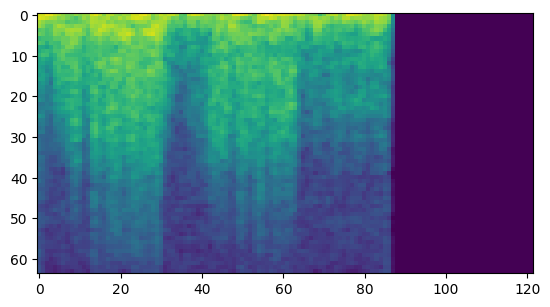

In [27]:
plt.imshow(temp_data[0][0][:,:,0].numpy())

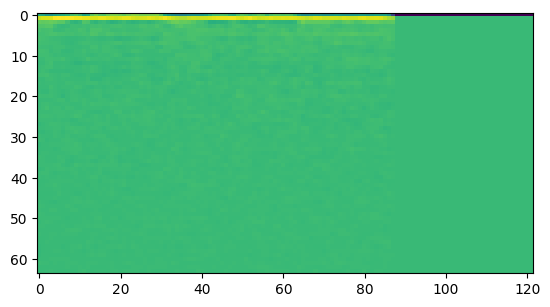

In [28]:
plt.imshow(temp_data[0][0][:,:,1].numpy())

In [33]:
history = model.fit(train_ds, validation_data=val_ds, epochs=300, callbacks=callbacks)

Epoch 1/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - AUC: 0.5489 - binary_accuracy: 0.5518 - loss: 0.6930
Epoch 1: val_loss improved from inf to 0.65674, saving model to best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 229ms/step - AUC: 0.5502 - binary_accuracy: 0.5526 - loss: 0.6926 - val_AUC: 0.6472 - val_binary_accuracy: 0.6121 - val_loss: 0.6567 - learning_rate: 0.0010
Epoch 2/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - AUC: 0.6694 - binary_accuracy: 0.6240 - loss: 0.6471
Epoch 2: val_loss improved from 0.65674 to 0.62921, saving model to best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - AUC: 0.6698 - binary_accuracy: 0.6244 - loss: 0.6469 - val_AUC: 0.7011 - val_binary_accuracy: 0.6590 - val_loss: 0.6292 - learning_rate: 0.0010
Epoch 3/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - AUC: 0.7059 - binary_accuracy: 0.6618 - loss: 0.6259
Epoch 3: val_loss improved from 0.62921 to 0.61232, saving model to best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - AUC: 0.7061

In [36]:
history.history

<function dict.keys>

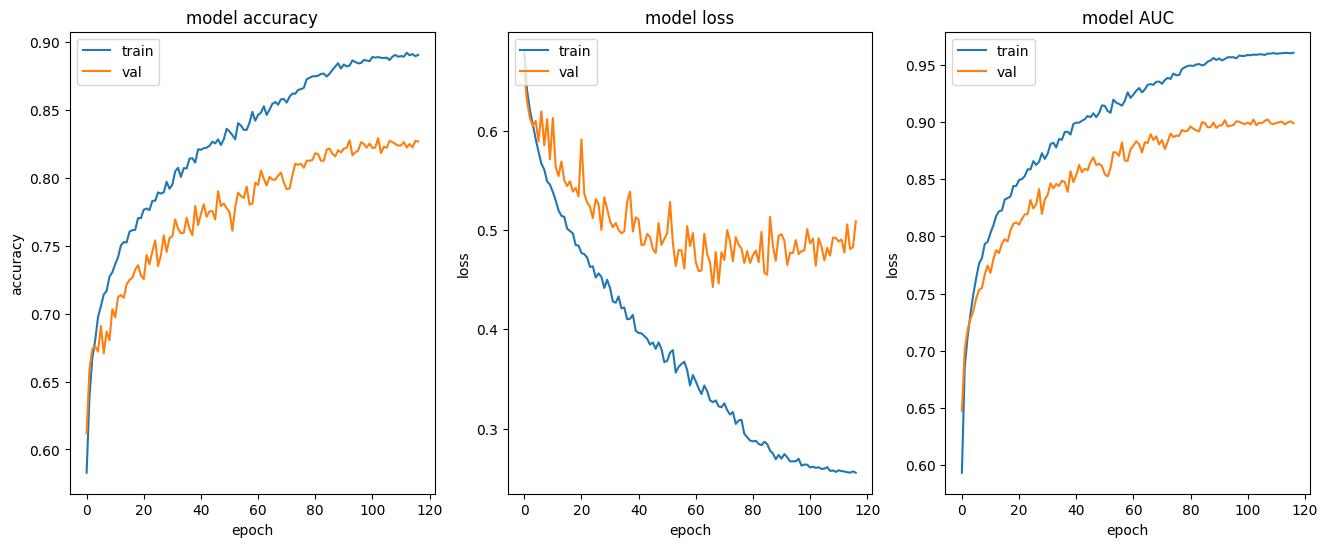

In [40]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

ax1.plot(history.history['binary_accuracy'])
ax1.plot(history.history['val_binary_accuracy'])
ax1.set_title('model accuracy')
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epoch')
ax1.legend(['train', 'val'], loc='upper left')

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('model loss')
ax2.set_ylabel('loss')
ax2.set_xlabel('epoch')
ax2.legend(['train', 'val'], loc='upper left')

ax3.plot(history.history['AUC'])
ax3.plot(history.history['val_AUC'])
ax3.set_title('model AUC')
ax3.set_ylabel('loss')
ax3.set_xlabel('epoch')
ax3.legend(['train', 'val'], loc='upper left')

In [51]:
# Predicciones de probabilidades (forma: [N, 2])
y_pred_prob = model.predict(val_ds)

# Umbral de clasificación binaria
y_pred = (y_pred_prob > 0.5).astype(int)  # → binariza: >0.5 → 1, ≤0.5 → 0

y_true = []
for _, label_batch in val_ds:
    y_true.append(label_batch.numpy())
y_true = np.concatenate(y_true, axis=0).astype(int)  # → [N, 2]

from sklearn.metrics import classification_report, multilabel_confusion_matrix

print("Crackles")
print(classification_report(y_true[:, 0], y_pred[:, 0], target_names=["No Crackles", "Crackles"]))

print("Wheezes")
print(classification_report(y_true[:, 1], y_pred[:, 1], target_names=["No Wheezes", "Wheezes"]))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
Crackles
              precision    recall  f1-score   support

 No Crackles       0.81      0.88      0.84      3328
    Crackles       0.83      0.74      0.79      2704

    accuracy                           0.82      6032
   macro avg       0.82      0.81      0.81      6032
weighted avg       0.82      0.82      0.82      6032

Wheezes
              precision    recall  f1-score   support

  No Wheezes       0.77      0.90      0.83      3574
     Wheezes       0.81      0.60      0.69      2458

    accuracy                           0.78      6032
   macro avg       0.79      0.75      0.76      6032
weighted avg       0.78      0.78      0.77      6032



In [57]:
matches = np.all(y_pred == y_true, axis=1) 

exact_match_acc = np.mean(matches)

print(f"Exact Match Accuracy (Crackles y Wheezes juntos): {exact_match_acc:.4f}")


Exact Match Accuracy (Crackles y Wheezes juntos): 0.6487


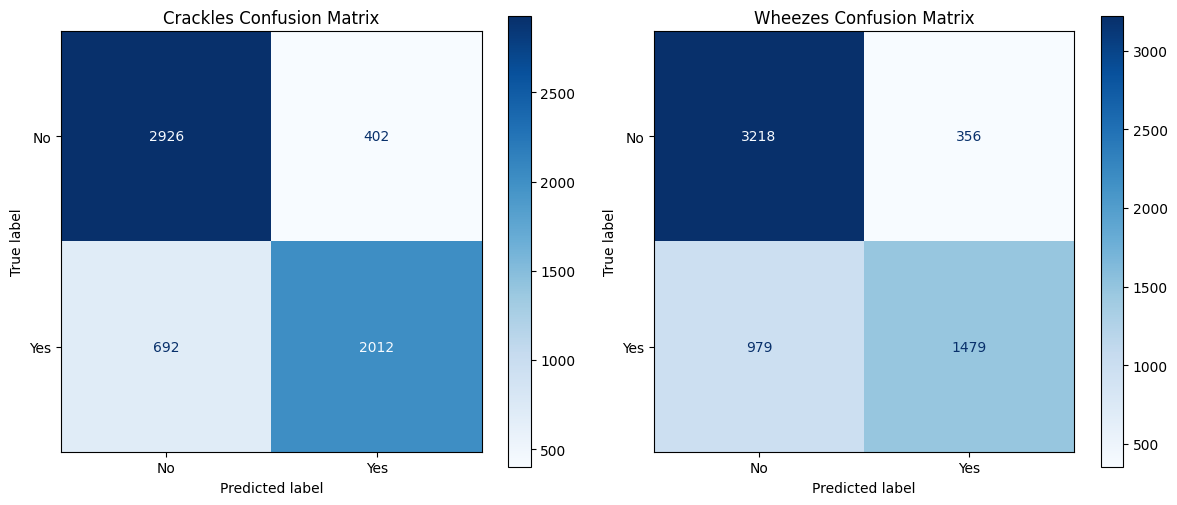

In [52]:
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener matrices por clase
cm = multilabel_confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, (cls_name, matrix) in enumerate(zip(["Crackles", "Wheezes"], cm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["No", "Yes"])
    disp.plot(ax=axs[i], cmap="Blues", values_format='d')
    axs[i].set_title(f"{cls_name} Confusion Matrix")

plt.tight_layout()
plt.show()


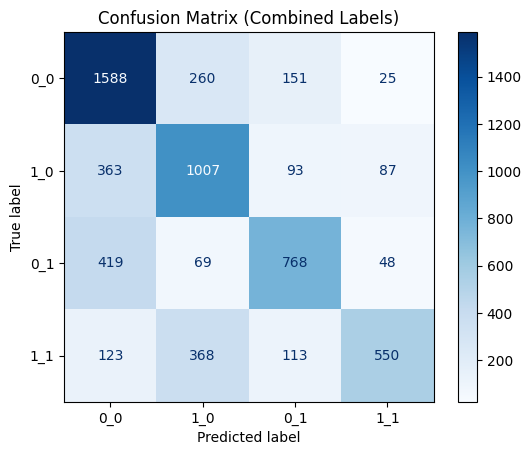

In [53]:
# Combinar las etiquetas binarias en una sola clase combinada
def combine_labels(y_bin):
    return [f"{a}_{b}" for a, b in y_bin]

labels_combined = ['0_0', '1_0', '0_1', '1_1']
y_true_comb = combine_labels(y_true)
y_pred_comb = combine_labels(y_pred)

cm = confusion_matrix(y_true_comb, y_pred_comb, labels=labels_combined)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_combined)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Combined Labels)")
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step


/tmp/ipykernel_337029/1435993314.py:47: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(features_2d[idx, 0], features_2d[idx, 1],


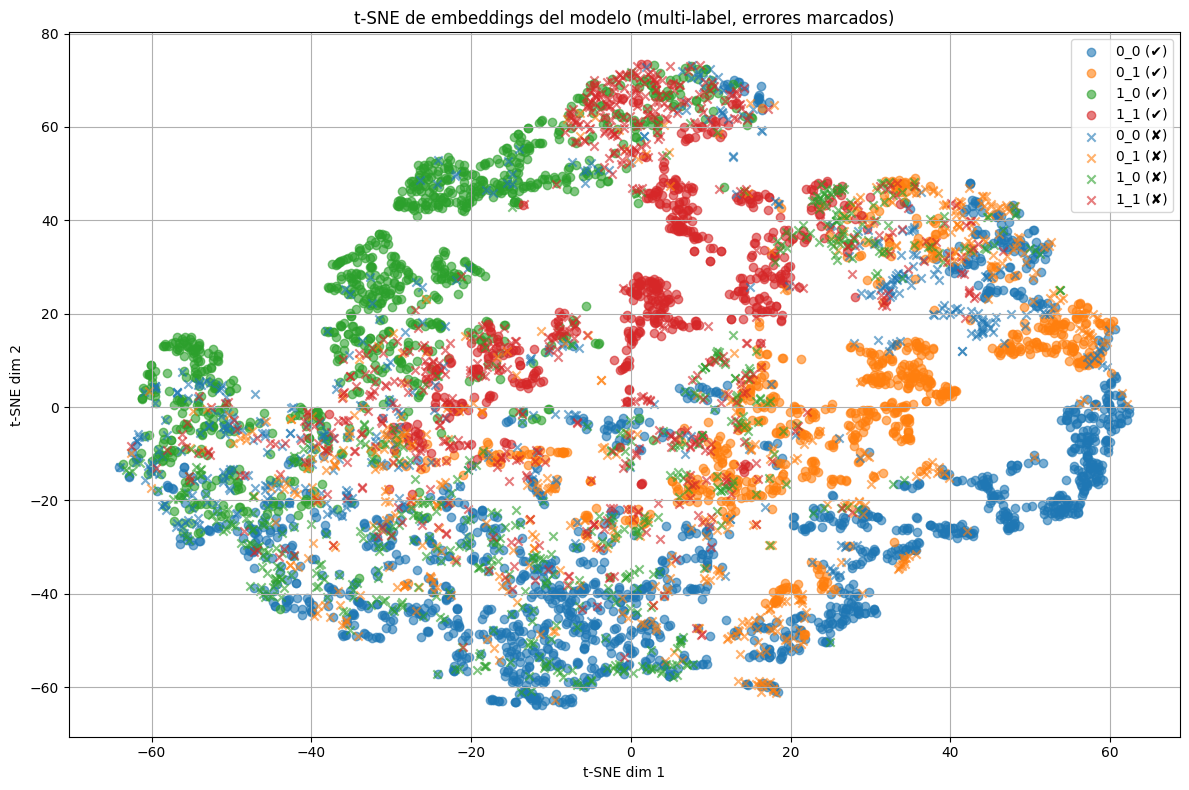

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import tensorflow as tf

# 1. Extraer embeddings desde la penúltima capa (ajusta el nombre si cambió)
feature_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer("glu_output").output)
features = feature_model.predict(val_ds, verbose=1)  # (N, feature_dim)

# 2. Obtener predicciones y etiquetas verdaderas
y_pred_prob = model.predict(val_ds)
y_pred_bin = (y_pred_prob > 0.5).astype(int)  # (N, 2)

y_true = []
for _, y in val_ds:
    y_true.append(y.numpy())
y_true = np.vstack(y_true)  # (N, 2)

# 3. Codificar combinación de clases para visualización
def label_to_str(crackles, wheezes):
    return f"{int(crackles)}_{int(wheezes)}"

labels_str = [label_to_str(c, w) for c, w in y_true]
labels_pred_str = [label_to_str(c, w) for c, w in y_pred_bin]
errors = np.array(labels_str) != np.array(labels_pred_str)

# 4. t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
features_2d = tsne.fit_transform(features)

# 5. Visualización
plt.figure(figsize=(12, 8))
label_set = sorted(set(labels_str))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
color_map = {label: color for label, color in zip(label_set, colors)}

# Correctos
for label in label_set:
    idx = (np.array(labels_str) == label) & (~errors)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1],
                label=f"{label} (✔)", color=color_map[label],
                marker='o', alpha=0.6)

# Incorrectos
for label in label_set:
    idx = (np.array(labels_str) == label) & (errors)
    plt.scatter(features_2d[idx, 0], features_2d[idx, 1],
                label=f"{label} (✘)", color=color_map[label],
                marker='x', alpha=0.6, edgecolors='k')

plt.title("t-SNE de embeddings del modelo (multi-label, errores marcados)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
